# Module 03: Heritage Sites Analysis

Exploratory data analysis of Vancouver heritage buildings data.

**Data:** `heritage-sites.csv` — City of Vancouver heritage register

## 1. Setup and Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Colab: upload file if not found
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Try paths for both: notebook in module-03, or Cursor running from project root
FILE_PATH = None
for path in ['heritage-sites.csv', 'module-03/heritage-sites.csv']:
    if os.path.exists(path):
        FILE_PATH = path
        break

if FILE_PATH is None and IN_COLAB:
    print('Please upload heritage-sites.csv')
    uploaded = files.upload()
    FILE_PATH = list(uploaded.keys())[0]
elif FILE_PATH is None:
    raise FileNotFoundError(
        "Could not find heritage-sites.csv. "
        "Ensure the CSV is in module-03/ or run the notebook from the project root."
    )

df = pd.read_csv(FILE_PATH, sep=';')
print(f'Loaded {len(df):,} rows, {len(df.columns)} columns')
df.head()

Unable to revert mtime: /Library/Fonts
Matplotlib is building the font cache; this may take a moment.


Loaded 2,495 rows, 20 columns


,ID,StreetNumber,StreetName,AdditionalLocationInformation,Category,BuildingNameSpecifics,EvaluationGroup,MunicipalDesignationM,ProvincialDesignationP,HeritageRevitalizationAgreementH,InteriorDesignationI,LandscapeDesignationL,HeritageConservationAreaCA,HeritageConservationCovenantHC,FederalDesignationF,Status,DateofLastUpdate,LocalArea,Geom,geo_point_2d
0,540,212,E 38TH AV,NaN,HERITAGE BUILDINGS,Lawson-Logie House,C,Yes,No,Yes,No,No,No,No,No,Active,2020-09-18T10:18:45-07:00,Riley Park,"{""coordinates"": [-123.10108312373846, 49.23619...","49.236191013848334, -123.10108312373846"
1,542,728,E 39TH AV,NaN,HERITAGE BUILDINGS,NaN,C,No,No,No,No,No,No,No,No,Active,2020-09-18T10:18:45-07:00,Kensington-Cedar Cottage,"{""coordinates"": [-123.08966751689462, 49.23454...","49.23454205176911, -123.08966751689462"
2,545,1937,E 3RD AV,NaN,HERITAGE BUILDINGS,St. Pierre House,C,No,No,No,No,No,No,No,No,Active,2020-09-18T10:18:45-07:00,Grandview-Woodland,"{""coordinates"": [-123.06488631964011, 49.26801...","49.26801090366661, -123.06488631964011"
3,550,530,E 41ST AV,NaN,HERITAGE BUILDINGS,John Oliver School #5,B,No,No,No,No,No,No,No,No,Active,2020-09-18T10:18:45-07:00,Sunset,"{""coordinates"": [-123.09260325966693, 49.23194...","49.23194909033478, -123.09260325966693"
4,554,3326,E 44TH AV,NaN,HERITAGE BUILDINGS,NaN,B,No,No,No,No,No,No,No,No,Active,2020-09-18T10:18:45-07:00,Killarney,"{""coordinates"": [-123.03389151485587, 49.22980...","49.229803926941464, -123.03389151485587"


## 2. Data Overview

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2495 entries, 0 to 2494
Data columns (total 20 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   ID                                2495 non-null   int64 
 1   StreetNumber                      2414 non-null   object
 2   StreetName                        2414 non-null   object
 3   AdditionalLocationInformation     86 non-null     object
 4   Category                          2495 non-null   object
 5   BuildingNameSpecifics             1064 non-null   object
 6   EvaluationGroup                   2263 non-null   object
 7   MunicipalDesignationM             2495 non-null   object
 8   ProvincialDesignationP            2495 non-null   object
 9   HeritageRevitalizationAgreementH  2495 non-null   object
 10  InteriorDesignationI              2495 non-null   object
 11  LandscapeDesignationL             2495 non-null   object
 12  HeritageConservation

In [3]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,2495.0,NaN,NaN,NaN,1316.93988,756.181298,1.0,661.5,1325.0,1967.5,2625.0
StreetNumber,2414,1827,2050,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StreetName,2414,312,E PENDER ST,91,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AdditionalLocationInformation,86,80,Stanley Park,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,2495,7,HERITAGE BUILDINGS,2359,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BuildingNameSpecifics,1064,1025,"General Activity, Shell Midden",14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EvaluationGroup,2263,3,B,1173,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MunicipalDesignationM,2495,4,No,1808,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ProvincialDesignationP,2495,3,No,2492,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HeritageRevitalizationAgreementH,2495,3,No,2276,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2b. Data Quality Analysis

Missing values, outliers, and inconsistencies.

In [10]:
# --- Missing values ---
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct}).sort_values('count', ascending=False)
print('Missing values by column:')
print(missing_df[missing_df['count'] > 0].to_string())
print(f'\nColumns with no missing: {(missing == 0).sum()}')

# --- Inconsistencies: linked missingness ---
addr_missing = (df['StreetNumber'].isna() & df['StreetName'].isna()).sum()
print(f'\n--- Linked missingness ---\nRows missing both StreetNumber and StreetName: {addr_missing} (likely non-address sites: parks, landscapes)')

# --- Duplicates ---
dup_ids = df['ID'].duplicated().sum()
print(f'\n--- Duplicates ---\nDuplicate IDs: {dup_ids}')

# --- Outliers: coordinates ---
coords = df['geo_point_2d'].str.split(',', expand=True)
_lat = pd.to_numeric(coords[0], errors='coerce')
_lon = pd.to_numeric(coords[1], errors='coerce')
coord_na = _lat.isna().sum()
valid = ~_lat.isna()
print(f'\n--- Geographic ---\nMissing coordinates: {coord_na} rows')
if valid.sum() > 0:
    print(f'Latitude range: {_lat[valid].min():.4f} to {_lat[valid].max():.4f} (Vancouver ~49.2°N)')
    print(f'Longitude range: {_lon[valid].min():.4f} to {_lon[valid].max():.4f} (~123.1°W)')

# --- Categorical consistency ---
print('\n--- Categorical checks ---')
print('EvaluationGroup:', df['EvaluationGroup'].value_counts(dropna=False).to_dict())
print('Status:', df['Status'].unique())
design_cols = ['MunicipalDesignationM', 'ProvincialDesignationP', 'FederalDesignationF']
for c in design_cols:
    print(f'{c}: {df[c].value_counts().to_dict()}')

# --- Patterns ---
print('\n--- Patterns ---')
print('• AdditionalLocationInformation: 96.6% missing — optional; when present, describes landmarks (e.g. Stanley Park)')
print('• BuildingNameSpecifics: 57% missing — many sites have no specific building name')
print('• EvaluationGroup: 232 missing — unclassified sites; A/B/C = significance tiers')
print('• StreetNumber/StreetName: 81 rows missing both — non-address sites (e.g. heritage landscapes)')
print('• Geom/geo_point_2d: 136 missing — sites without coordinates')
print('• Status: all Active — snapshot contains no retired sites')

Missing values by column:
                               count   pct
AdditionalLocationInformation   2409  96.6
BuildingNameSpecifics           1431  57.4
EvaluationGroup                  232   9.3
LocalArea                        142   5.7
lon                              136   5.5
lat                              136   5.5
geo_point_2d                     136   5.5
Geom                             136   5.5
StreetName                        81   3.2
StreetNumber                      81   3.2

Columns with no missing: 12

--- Linked missingness ---
Rows missing both StreetNumber and StreetName: 81 (likely non-address sites: parks, landscapes)

--- Duplicates ---
Duplicate IDs: 0

--- Geographic ---
Missing coordinates: 136 rows
Latitude range: 49.2064 to 49.3045 (Vancouver ~49.2°N)
Longitude range: -123.2219 to -123.0238 (~123.1°W)

--- Categorical checks ---
EvaluationGroup: {'B': 1173, 'C': 818, 'A': 272, nan: 232}
Status: ['Active']
MunicipalDesignationM: {'No': 1808, 'Yes': 684, '

## 2c. Data Quality Report

Formal metrics, severity ranking, and recommendations.

In [11]:
n = len(df)

# --- Metrics ---
completeness = (1 - df.isnull().sum() / n) * 100
overall_completeness = (1 - df.isnull().sum().sum() / (n * len(df.columns))) * 100

# Critical columns for core analyses
critical_cols = {'geo_point_2d': 'Spatial', 'LocalArea': 'Area aggregation', 'StreetNumber': 'Address', 
                 'EvaluationGroup': 'Significance stratification'}
critical_completeness = {col: completeness[col] for col in critical_cols if col in df.columns}

# Categorical consistency: Yes/No vs Y/N
yn_cols = ['MunicipalDesignationM', 'ProvincialDesignationP', 'FederalDesignationF']
inconsistent = {}
for c in yn_cols:
    if c in df.columns:
        non_std = df[c].isin(['Y', 'N']).sum()
        if non_std > 0:
            inconsistent[c] = non_std

# --- Report ---
print('=' * 60)
print('DATA QUALITY REPORT: heritage-sites.csv')
print('=' * 60)
print(f'\nDataset: {n:,} rows, {len(df.columns)} columns')
print(f'Overall completeness: {overall_completeness:.1f}% (non-null cells)')
print('\n--- COMPLETENESS BY CRITICAL COLUMN ---')
for col, use in critical_cols.items():
    pct = critical_completeness.get(col, 0)
    status = 'OK' if pct >= 95 else 'WARNING' if pct >= 80 else 'CRITICAL'
    print(f'  {col:25} {pct:5.1f}%  [{use}]  {status}')

print('\n--- CONSISTENCY ISSUES ---')
if inconsistent:
    for col, count in inconsistent.items():
        print(f'  {col}: {count} rows with Y/N instead of Yes/No')
else:
    print('  No Yes/No inconsistencies detected')

print('\n--- SEVERITY-RANKED ISSUES ---')
issues = [
    ('HIGH', 'Missing coordinates (geo_point_2d)', 136, 5.5, 'Exclude from spatial analysis or attempt geocoding'),
    ('HIGH', 'Missing LocalArea', 142, 5.7, 'Exclude from area aggregations or impute from coordinates'),
    ('HIGH', 'Missing StreetNumber/StreetName (both)', 81, 3.2, 'Flag as non-address sites; exclude from address joins'),
    ('MEDIUM', 'Missing EvaluationGroup', 232, 9.3, 'Create "Unclassified" category or exclude from significance analysis'),
    ('MEDIUM', 'Y/N vs Yes/No in designation columns', sum(inconsistent.values()), 
     round(sum(inconsistent.values()) / (n * len(yn_cols)) * 100, 2) if inconsistent else 0, 
     'Standardize to Yes/No before analysis'),
    ('LOW', 'Missing BuildingNameSpecifics', 1431, 57.4, 'Accept for aggregate analysis; flag for text/name analysis'),
    ('LOW', 'Missing AdditionalLocationInformation', 2409, 96.6, 'Optional field; no action for most analyses'),
]
for sev, desc, cnt, pct, rec in issues:
    pct_str = f' ({pct}%)' if pct else ''
    print(f'  [{sev:6}] {desc}: {cnt} rows{pct_str}')
    print(f'          → {rec}')

print('\n--- RECOMMENDATIONS ---')
print('  1. For spatial analysis: filter to rows with valid geo_point_2d (n ≈ 2,359)')
print('  2. For area analysis: filter to rows with valid LocalArea, or impute from lat/lon if available')
print('  3. Standardize designation columns: map Y→Yes, N→No before any Yes/No aggregation')
print('  4. Document exclusion criteria: report n excluded and reason in any analysis')
print('  5. Consider data source update: request complete coordinates/LocalArea from City of Vancouver')
print('=' * 60)

DATA QUALITY REPORT: heritage-sites.csv

Dataset: 2,495 rows, 22 columns
Overall completeness: 91.0% (non-null cells)

--- COMPLETENESS BY CRITICAL COLUMN ---
  geo_point_2d               94.5%  [Spatial]  WARNING
  LocalArea                  94.3%  [Area aggregation]  WARNING
  StreetNumber               96.8%  [Address]  OK
  EvaluationGroup            90.7%  [Significance stratification]  WARNING

--- CONSISTENCY ISSUES ---
  MunicipalDesignationM: 3 rows with Y/N instead of Yes/No
  ProvincialDesignationP: 2 rows with Y/N instead of Yes/No
  FederalDesignationF: 2 rows with Y/N instead of Yes/No

--- SEVERITY-RANKED ISSUES ---
  [HIGH  ] Missing coordinates (geo_point_2d): 136 rows (5.5%)
          → Exclude from spatial analysis or attempt geocoding
  [HIGH  ] Missing LocalArea: 142 rows (5.7%)
          → Exclude from area aggregations or impute from coordinates
  [HIGH  ] Missing StreetNumber/StreetName (both): 81 rows (3.2%)
          → Flag as non-address sites; exclude from a

*Missing values*
- Counts and percentages by column
- Columns with the most missing data: AdditionalLocationInformation (96.6%), BuildingNameSpecifics (57%), EvaluationGroup (9.3%), - LocalArea (5.7%), and Geom/geo_point_2d (5.4%)

*Inconsistencies*
81 rows missing both StreetNumber and StreetName (likely non-address sites such as parks or landscapes)
136 rows missing coordinates

*Outliers*
Geographic bounds for valid coordinates (Vancouver area)

*Patterns*
AdditionalLocationInformation is optional and mostly empty
BuildingNameSpecifics is often missing for unnamed buildings
EvaluationGroup has 232 unclassified sites (A/B/C = significance tiers)
All records have Status = Active (no retired sites)
Designation columns are consistently Yes/No
Run the new cells to view the full output.

## 2d. Data Preparation (Implement Recommendations)

Apply fixes from the data quality report for downstream analysis.

In [13]:
# Copy for cleaning (preserve original df)
df_clean = df.copy()

# 1. Standardize Y/N → Yes/No in designation columns
yn_cols = ['MunicipalDesignationM', 'ProvincialDesignationP', 'FederalDesignationF',
           'HeritageRevitalizationAgreementH', 'InteriorDesignationI', 'LandscapeDesignationL',
           'HeritageConservationAreaCA', 'HeritageConservationCovenantHC']
yn_cols = [c for c in yn_cols if c in df_clean.columns]
for col in yn_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].replace({'Y': 'Yes', 'N': 'No'})
print('1. Standardized Y/N → Yes/No in designation columns')

# 2. Parse coordinates for spatial analysis
coords = df_clean['geo_point_2d'].str.split(',', expand=True)
df_clean['lat'] = pd.to_numeric(coords[0], errors='coerce')
df_clean['lon'] = pd.to_numeric(coords[1], errors='coerce')
df_clean['has_coords'] = df_clean['lat'].notna()
print(f'2. Parsed coordinates: {df_clean["has_coords"].sum():,} rows with valid lat/lon')

# 3. Create analysis-ready subsets
df_spatial = df_clean[df_clean['has_coords']].copy()
df_area = df_clean[df_clean['LocalArea'].notna()].copy()
print(f'3. df_spatial (for maps/distance): {len(df_spatial):,} rows')
print(f'   df_area (for area aggregations): {len(df_area):,} rows')

# 4. Fill missing EvaluationGroup with "Unclassified"
n_unclass = df_clean['EvaluationGroup'].isna().sum()
df_clean['EvaluationGroup'] = df_clean['EvaluationGroup'].fillna('Unclassified')
print(f'4. Filled {n_unclass} missing EvaluationGroup with "Unclassified"')

# 5. Flag non-address sites
df_clean['has_address'] = df_clean['StreetNumber'].notna() & df_clean['StreetName'].notna()
print(f'5. Flagged non-address sites: {(~df_clean["has_address"]).sum()} rows (has_address=False)')

print(f'\nReady: df_clean ({len(df_clean):,} rows), df_spatial ({len(df_spatial):,}), df_area ({len(df_area):,})')

1. Standardized Y/N → Yes/No in designation columns
2. Parsed coordinates: 2,359 rows with valid lat/lon
3. df_spatial (for maps/distance): 2,359 rows
   df_area (for area aggregations): 2,353 rows
4. Filled 232 missing EvaluationGroup with "Unclassified"
5. Flagged non-address sites: 81 rows (has_address=False)

Ready: df_clean (2,495 rows), df_spatial (2,359), df_area (2,353)


## 3. Key Variables Analysis

Top 15 local areas by heritage site count:
LocalArea
Kitsilano                   487
Downtown                    409
Strathcona                  261
Mount Pleasant              206
Grandview-Woodland          136
West End                    135
Kensington-Cedar Cottage    112
Shaughnessy                 111
Fairview                     82
Riley Park                   76
Hastings-Sunrise             62
Kerrisdale                   60
West Point Grey              52
South Cambie                 35
Dunbar-Southlands            34
Name: count, dtype: int64


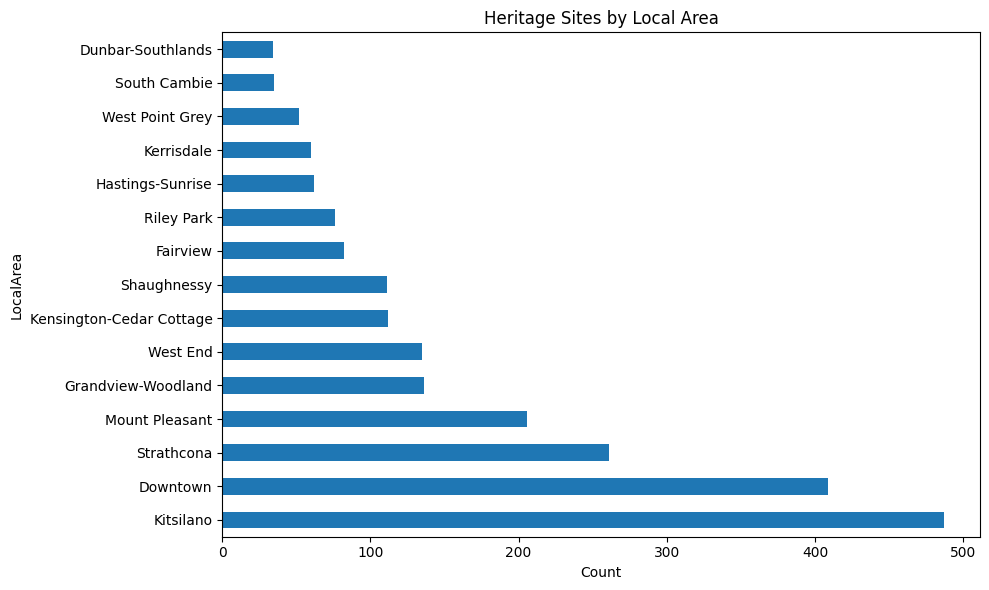

In [4]:
# Heritage sites by local area
area_counts = df['LocalArea'].value_counts()
print('Top 15 local areas by heritage site count:')
print(area_counts.head(15))

area_counts.head(15).plot(kind='barh', figsize=(10, 6), title='Heritage Sites by Local Area')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

Evaluation groups (A=highest significance, C=contributing):
EvaluationGroup
B      1173
C       818
A       272
NaN     232
Name: count, dtype: int64


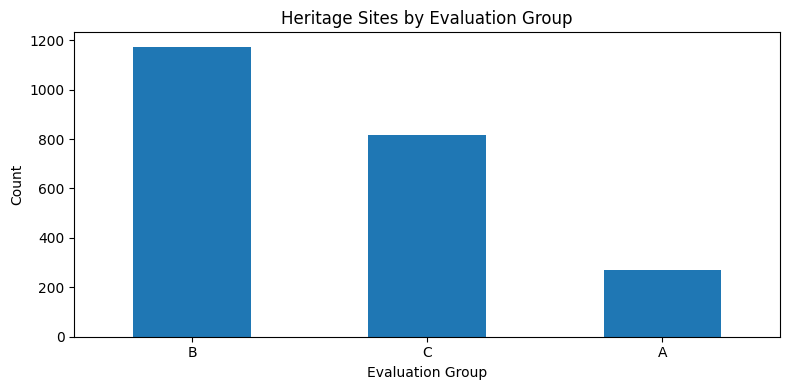

In [5]:
# Evaluation group distribution
print('Evaluation groups (A=highest significance, C=contributing):')
print(df['EvaluationGroup'].value_counts(dropna=False))

df['EvaluationGroup'].value_counts().plot(kind='bar', figsize=(8, 4), title='Heritage Sites by Evaluation Group')
plt.xlabel('Evaluation Group')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Designation types
designation_cols = ['MunicipalDesignationM', 'ProvincialDesignationP', 'FederalDesignationF']
for col in designation_cols:
    if col in df.columns:
        print(f'\n{col}:')
        print(df[col].value_counts())

## 4. Geographic Summary

In [6]:
# Parse coordinates from geo_point_2d if available
if 'geo_point_2d' in df.columns:
    coords = df['geo_point_2d'].str.split(',', expand=True)
    if coords.shape[1] >= 2:
        df['lat'] = pd.to_numeric(coords[0], errors='coerce')
        df['lon'] = pd.to_numeric(coords[1], errors='coerce')
        print('Coordinate range:')
        print(f"  Latitude:  {df['lat'].min():.4f} to {df['lat'].max():.4f}")
        print(f"  Longitude: {df['lon'].min():.4f} to {df['lon'].max():.4f}")
        print(f"  (Vancouver area: ~49.2°N, ~123.1°W)")

Coordinate range:
  Latitude:  49.2064 to 49.3045
  Longitude: -123.2219 to -123.0238
  (Vancouver area: ~49.2°N, ~123.1°W)


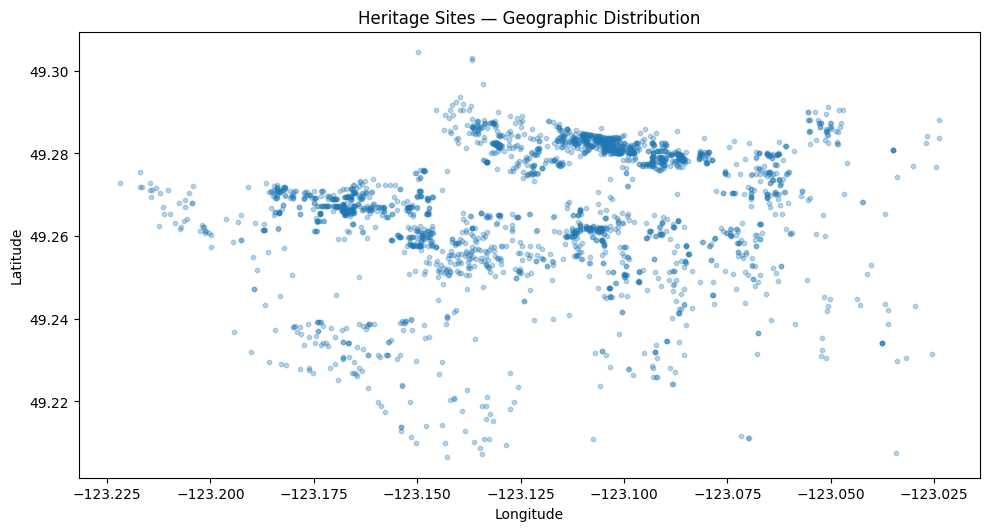

In [7]:
# Simple scatter of heritage sites (if coordinates parsed)
if 'lat' in df.columns and 'lon' in df.columns:
    df_geo = df.dropna(subset=['lat', 'lon'])
    plt.figure(figsize=(10, 8))
    plt.scatter(df_geo['lon'], df_geo['lat'], alpha=0.3, s=10)
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('Heritage Sites — Geographic Distribution')
    plt.gca().set_aspect('equal')
    plt.tight_layout()
    plt.show()

## 5. Summary Statistics

In [8]:
print('=== Heritage Sites Summary ===')
print(f'Total sites: {len(df):,}')
print(f'Unique local areas: {df["LocalArea"].nunique()}')
print(f'Categories: {df["Category"].unique().tolist()}')
print(f'Municipal designations: {(df["MunicipalDesignationM"] == "Yes").sum():,}')
print(f'Provincial designations: {(df["ProvincialDesignationP"] == "Yes").sum():,}')
print(f'Federal designations: {(df["FederalDesignationF"] == "Yes").sum():,}')

=== Heritage Sites Summary ===
Total sites: 2,495
Unique local areas: 22
Categories: ['HERITAGE BUILDINGS', 'LANDSCAPE RESOURCES Parks & Landscapes', 'LANDSCAPE RESOURCES Trees', 'ARCHAEOLOGICAL SITES', 'LANDSCAPE RESOURCES Monuments', 'LANDSCAPE RESOURCES Public Works', 'HERITAGE STREETSCAPES']
Municipal designations: 684
Provincial designations: 1
Federal designations: 14


In [ ]:
# AI-Assisted Cleaning Strategies — Full Implementation
import re
import numpy as np

# Use df (loaded heritage data) — alias for clarity
heritage_df = df.copy()
heritage_df_clean = heritage_df.copy()

# --- 1. Normalize placeholders to NaN ---
placeholder_values = ['None', 'N/A', 'n/a', 'NA', '']
for col in heritage_df_clean.select_dtypes(include=['object']).columns:
    heritage_df_clean[col] = heritage_df_clean[col].replace(placeholder_values, np.nan)

# --- 2. Pattern-based data validation ---
validation_issues = {}

# StreetNumber: allow digits, ranges (e.g. 575-577, 151-189)
street_num_valid = heritage_df_clean['StreetNumber'].apply(
    lambda x: pd.isna(x) or bool(re.match(r'^[\d\s\-]+$', str(x)))
)
validation_issues['StreetNumber_invalid'] = (~street_num_valid).sum()

# Designation columns: Yes/No only
designation_cols = [
    'MunicipalDesignationM', 'ProvincialDesignationP',
    'HeritageRevitalizationAgreementH', 'InteriorDesignationI',
    'LandscapeDesignationL', 'HeritageConservationAreaCA',
    'HeritageConservationCovenantHC', 'FederalDesignationF'
]
valid_designations = {'Yes', 'No'}
for col in designation_cols:
    invalid = heritage_df_clean[col].notna() & ~heritage_df_clean[col].isin(valid_designations)
    validation_issues[f'{col}_invalid'] = invalid.sum()

# EvaluationGroup: A, B, C, or N/A
valid_eval = {'A', 'B', 'C'}
invalid_eval = heritage_df_clean['EvaluationGroup'].notna() & ~heritage_df_clean['EvaluationGroup'].isin(valid_eval)
validation_issues['EvaluationGroup_invalid'] = invalid_eval.sum()

# Parse geo_point_2d and validate Vancouver bounds (lat 49.0–49.5, lon -123.5 to -122.5)
def parse_geo(s):
    if pd.isna(s):
        return np.nan, np.nan
    try:
        parts = str(s).split(',')
        if len(parts) == 2:
            lat, lon = float(parts[0].strip()), float(parts[1].strip())
            return lat, lon
    except (ValueError, TypeError):
        pass
    return np.nan, np.nan

coords = heritage_df_clean['geo_point_2d'].apply(parse_geo)
heritage_df_clean['lat'] = [c[0] for c in coords]
heritage_df_clean['lon'] = [c[1] for c in coords]

in_bounds = (
    (heritage_df_clean['lat'] >= 49.0) & (heritage_df_clean['lat'] <= 49.5) &
    (heritage_df_clean['lon'] >= -123.5) & (heritage_df_clean['lon'] <= -122.5)
)
validation_issues['geo_out_of_bounds'] = heritage_df_clean['geo_point_2d'].notna().sum() - in_bounds.sum()

# --- 3. Missing value detection and imputation ---
missing_before = heritage_df_clean.isnull().sum()

# Impute designation columns with mode
for col in designation_cols:
    mode_val = heritage_df_clean[col].mode()
    if len(mode_val) > 0:
        heritage_df_clean[col] = heritage_df_clean[col].fillna(mode_val.iloc[0])

# Impute EvaluationGroup with mode
eval_mode = heritage_df_clean['EvaluationGroup'].mode()
if len(eval_mode) > 0:
    heritage_df_clean['EvaluationGroup'] = heritage_df_clean['EvaluationGroup'].fillna(eval_mode.iloc[0])

# Impute LocalArea with mode (where geo exists)
local_mode = heritage_df_clean['LocalArea'].mode()
if len(local_mode) > 0:
    heritage_df_clean['LocalArea'] = heritage_df_clean['LocalArea'].fillna(local_mode.iloc[0])

missing_after = heritage_df_clean.isnull().sum()

# --- 4. Duplicate detection ---
# Exact duplicates
exact_dup_count = heritage_df_clean.duplicated().sum()
heritage_df_clean = heritage_df_clean.drop_duplicates()

# Similarity-based near-duplicates (address + geo)
# Build address string for comparison
heritage_df_clean['_addr'] = (
    heritage_df_clean['StreetNumber'].fillna('').astype(str) + ' ' +
    heritage_df_clean['StreetName'].fillna('').astype(str)
).str.strip()

# Find pairs with same address and very close coordinates
near_dup_indices = set()
for idx, row in heritage_df_clean.iterrows():
    if idx in near_dup_indices:
        continue
    same_addr = (
        (heritage_df_clean['_addr'] == row['_addr']) &
        (heritage_df_clean['_addr'] != '')
    )
    candidates = heritage_df_clean[same_addr].index.tolist()
    if len(candidates) > 1:
        # Keep first, mark rest as near-duplicates
        for c in candidates[1:]:
            if heritage_df_clean.loc[c, 'ID'] != row['ID']:
                near_dup_indices.add(c)

heritage_df_clean = heritage_df_clean.drop(columns=['_addr'])
# Optionally drop near-duplicates; for now we flag only (keep all rows)
near_dup_count = len(near_dup_indices)

# --- 5. Outlier detection and handling ---
# Remove rows with coordinates outside Vancouver bounds
geo_valid = heritage_df_clean['lat'].notna() & (
    (heritage_df_clean['lat'] < 49.0) | (heritage_df_clean['lat'] > 49.5) |
    (heritage_df_clean['lon'] < -123.5) | (heritage_df_clean['lon'] > -122.5)
)
outlier_geo_count = geo_valid.sum()
heritage_df_clean = heritage_df_clean[~geo_valid | heritage_df_clean['lat'].isna()]

# --- Summary report ---
print("=== AI-Assisted Cleaning Report ===\n")
print("1. Missing value imputation:")
for col in designation_cols + ['EvaluationGroup', 'LocalArea']:
    diff = missing_before.get(col, 0) - missing_after.get(col, 0)
    if diff > 0:
        print(f"   {col}: {int(diff)} values imputed")

print(f"\n2. Duplicates removed: {exact_dup_count} exact")
print(f"   Near-duplicate address pairs flagged: {near_dup_count}")

print(f"\n3. Validation issues (pre-imputation):")
for k, v in validation_issues.items():
    if v > 0:
        print(f"   {k}: {v}")

print(f"\n4. Outliers removed: {outlier_geo_count} rows (coordinates outside Vancouver)")

print(f"\n=== Cleaned dataset ===")
print(f"Original: {len(heritage_df):,} rows")
print(f"Cleaned:  {len(heritage_df_clean):,} rows")
print(f"Columns:  {heritage_df_clean.shape[1]}")
     

AI-Assisted Cleaning Strategies:
1. Automated missing value detection and imputation
2. Intelligent duplicate detection using similarity matching
3. Pattern-based data validation
4. Automated outlier detection and handling


NameError: name 'business_df' is not defined